# Introduction to `lamatrix`: Sparse Spline Models

Some models that we make are inherrently sparse. An example might be a spline model with a high number of knots; many of the components in such a model are full of zeros. Because of this, it can be helpful to use the `sparse` library from `scipy`, which enables us to use linear algebra without storing zeros in memory. `lamatrix` has some support for sparse models, which we will show briefly here.

In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import sys

In [3]:
x = np.arange(-5, 5, 0.001)
y = np.random.normal(size=len(x))
y = np.convolve(y, np.ones(1000), mode='same') + np.random.normal(0, 0.3, size=len(x))
ye = np.ones(len(x)) * 0.3

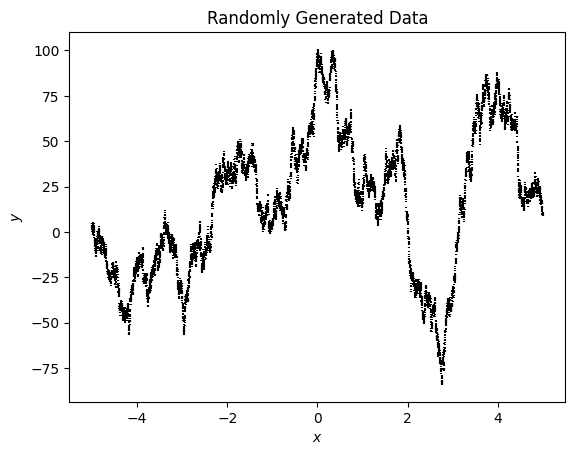

In [4]:
fig, ax = plt.subplots()
ax.errorbar(x, y, ye, ls='', c='k')
ax.set(xlabel='$x$', ylabel='$y$', title='Randomly Generated Data');

Here we have created a simple dataset with correlated noise in it. We want to fit this with a spline. We can use the `Spline` model

In [5]:
from lamatrix import Spline

We know we need a small knot spacing (i.e. a large number of knots) to fit this trend

In [7]:
knot_spacing = 0.05
order = 3
knots = np.arange(-5 - knot_spacing * (order - 1), 5 + (knot_spacing * (order - 1)) + knot_spacing, knot_spacing)

In [8]:
model = Spline('x', knots=knots, order=order)

In [9]:
model.fit(x=x, data=y)

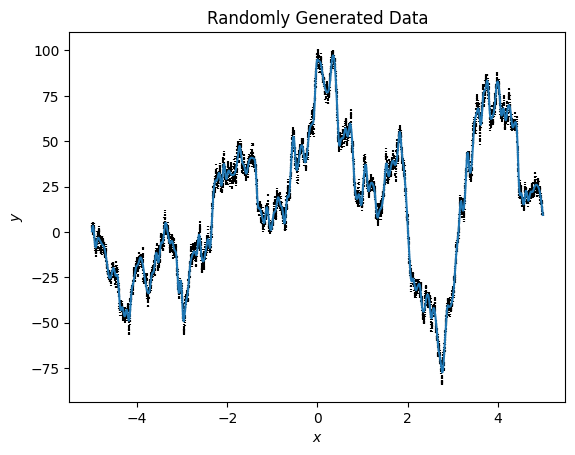

In [10]:
fig, ax = plt.subplots()
ax.errorbar(x, y, ye, ls='', c='k')
ax.plot(x, model.evaluate(x=x))
ax.set(xlabel='$x$', ylabel='$y$', title='Randomly Generated Data');

This fits nicely, however when we look at the size of the design matrix we see

In [11]:
model.design_matrix(x=x).nbytes

16160000

This is large in memory, taking up megabytes of memory currently. If we sum up the number of zeros in the design matrix we see that it's almost all zeros.

In [12]:
(model.design_matrix(x=x) == 0).sum()/(model.width * len(x))

0.9851490099009901

If we were to try to fit more data points or use more knots, this might become too large to fit in memory. We can use the `SparseSpline` in stead

In [13]:
from lamatrix import SparseSpline

In [14]:
model_sparse = SparseSpline('x', knots=knots, order=order)

In [15]:
model_sparse.fit(x=x, data=y)

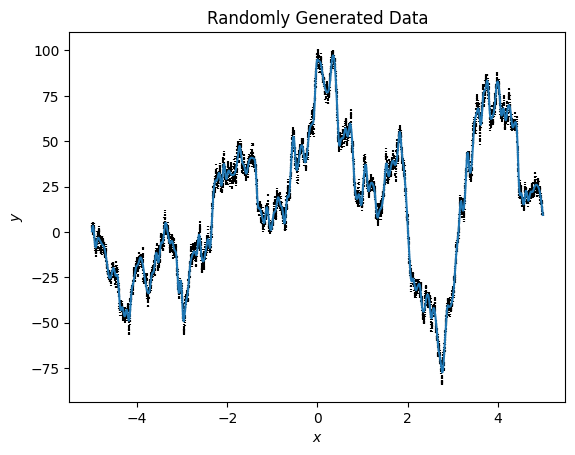

In [16]:
fig, ax = plt.subplots()
ax.errorbar(x, y, ye, ls='', c='k')
ax.plot(x, model.evaluate(x=x))
ax.set(xlabel='$x$', ylabel='$y$', title='Randomly Generated Data');

This provides as good of a fit to our data but when we look at the design matrix we see this is much smaller in memory

In [17]:
model_sparse.design_matrix(x=x).data.nbytes

239992

In [18]:
239992/16160000

0.0148509900990099

This model is 1% of the size in memory of the non sparse model!

Currently only `Spline`s are implemented with a `sparse` version (as most other models within `lamatrix` are not well suited to being sparse). It is not possible to combine the `SparseSpline` with other model types currently, but this may be updated in the future.